In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

In [3]:
df = pd.read_csv("../data/titanic.csv")

In [4]:
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [5]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [6]:
df.tail()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.00,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.00,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.45,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.00,C148,C
890,891,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.75,NaN,Q


In [7]:

rows, columns = df.shape

print("Rows :", rows)
print("Columns :", columns)

Rows : 891
Columns : 12


In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [9]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='str')

In [10]:
df.dtypes

PassengerId      int64
Survived         int64
Pclass           int64
Name               str
Sex                str
Age            float64
SibSp            int64
Parch            int64
Ticket             str
Fare           float64
Cabin              str
Embarked           str
dtype: object

In [11]:
df.dtypes.value_counts()

int64      5
str        5
float64    2
Name: count, dtype: int64

In [12]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [13]:
df.duplicated().sum()

np.int64(0)

In [14]:
df = df.drop_duplicates()

In [15]:
# Missing Values Table

missing_data = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Percentage": (df.isnull().sum() / len(df)) * 100
})

missing_data

,Missing Values,Percentage
PassengerId,0,0.000000
Survived,0,0.000000
Pclass,0,0.000000
Name,0,0.000000
Sex,0,0.000000
Age,177,19.865320
SibSp,0,0.000000
Parch,0,0.000000
Ticket,0,0.000000
Fare,0,0.000000


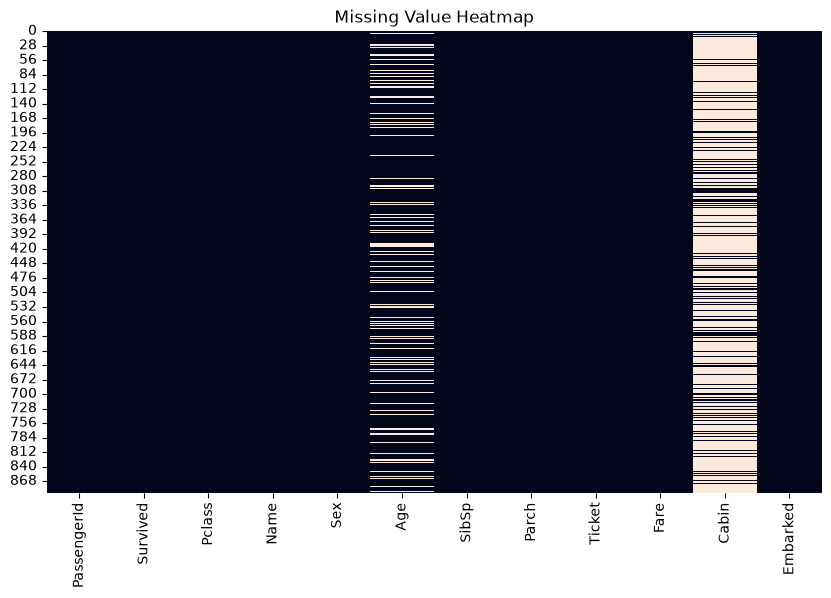

In [16]:
plt.figure(figsize=(10,6))
sns.heatmap(df.isnull(), cbar=False)
plt.title("Missing Value Heatmap")
plt.show()

### Observation

- Age contains several missing values.
- Cabin has the highest number of missing values.
- Embarked has very few missing values.

In [17]:
numerical_columns = df.select_dtypes(include=np.number).columns

print(numerical_columns)

Index(['PassengerId', 'Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare'], dtype='str')


In [18]:
categorical_columns = df.select_dtypes(include="object").columns

print(categorical_columns)

Index(['Name', 'Sex', 'Ticket', 'Cabin', 'Embarked'], dtype='str')


/var/folders/v3/dc_tn6314bv09gpz6x0ns0l80000gn/T/ipykernel_72146/1123855639.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = df.select_dtypes(include="object").columns


In [19]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [20]:
missing_data = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Percentage": (df.isnull().sum()/len(df))*100
})

missing_data

,Missing Values,Percentage
PassengerId,0,0.000000
Survived,0,0.000000
Pclass,0,0.000000
Name,0,0.000000
Sex,0,0.000000
Age,177,19.865320
SibSp,0,0.000000
Parch,0,0.000000
Ticket,0,0.000000
Fare,0,0.000000


In [21]:
## Question 1
#Display the number of rows where the values in the Age column are missing.
print(df["Age"].isnull().sum())

177


In [22]:
## Question 2
#Display the number of passengers who survived.
print(df[df["Survived"] == 1].shape[0])

342


In [23]:
## Question 3
#Display the number of people dead.
print(df[df["Survived"] == 0].shape[0])

549


In [24]:
## Question 4
#Drop the rows where Age column has missing values.

df_no_age = df.dropna(subset=["Age"])
df_no_age.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [25]:
## Question 5
#Display the names and ages of survived people.
df[df["Survived"] == 1][["Name", "Age"]]

,Name,Age
1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",38.0
2,"Heikkinen, Miss. Laina",26.0
3,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",35.0
8,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",27.0
9,"Nasser, Mrs. Nicholas (Adele Achem)",14.0
...,...,...
875,"Najib, Miss. Adele Kiamie ""Jane""",15.0
879,"Potter, Mrs. Thomas Jr (Lily Alexenia Wilson)",56.0
880,"Shelley, Mrs. William (Imanita Parrish Hall)",25.0
887,"Graham, Miss. Margaret Edith",19.0


In [26]:
## Question 6
#Display only numeric columns.
df.select_dtypes(include=np.number)

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
0,1,0,3,22.0,1,0,7.2500
1,2,1,1,38.0,1,0,71.2833
2,3,1,3,26.0,0,0,7.9250
3,4,1,1,35.0,1,0,53.1000
4,5,0,3,35.0,0,0,8.0500
...,...,...,...,...,...,...,...
886,887,0,2,27.0,0,0,13.0000
887,888,1,1,19.0,0,0,30.0000
888,889,0,3,NaN,1,2,23.4500
889,890,1,1,26.0,0,0,30.0000


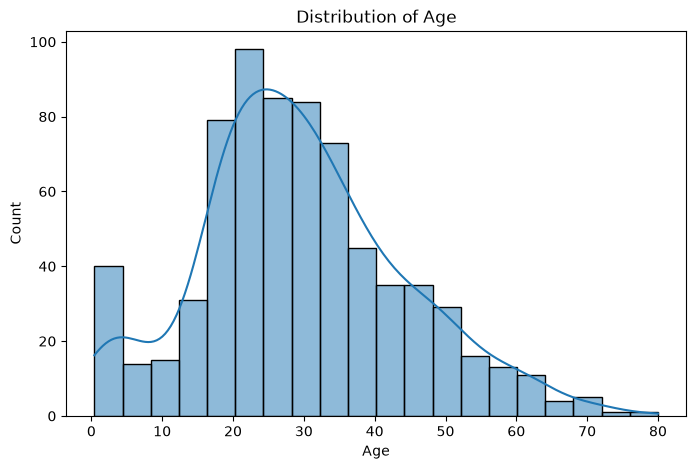

In [27]:
## Question 7
#Distribution plot of Age.
plt.figure(figsize=(8,5))
sns.histplot(df["Age"], kde=True)
plt.title("Distribution of Age")
plt.show()

### Observation

- Most passengers were between 20 and 40 years old.
- Very few passengers were above 70 years.
- The age distribution is slightly right-skewed.

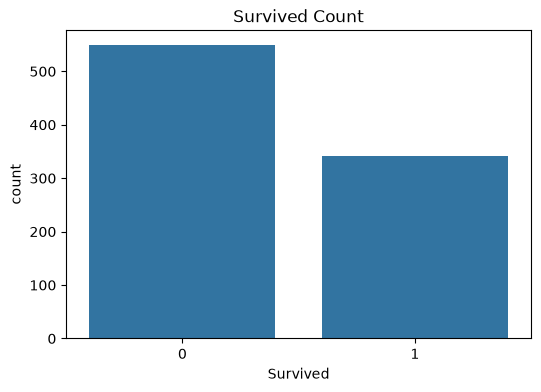

In [28]:
## Question 8
##Count plot of Survived.
plt.figure(figsize=(6,4))
sns.countplot(x="Survived", data=df)
plt.title("Survived Count")
plt.show()

### Observation

- More passengers died than survived.

In [29]:
## Question 9
#Display males and females who survived.
survivors = df[df["Survived"] == 1]

survivors[["Name", "Sex", "Age"]]

,Name,Sex,Age
1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0
2,"Heikkinen, Miss. Laina",female,26.0
3,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0
8,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0
9,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0
...,...,...,...
875,"Najib, Miss. Adele Kiamie ""Jane""",female,15.0
879,"Potter, Mrs. Thomas Jr (Lily Alexenia Wilson)",female,56.0
880,"Shelley, Mrs. William (Imanita Parrish Hall)",female,25.0
887,"Graham, Miss. Margaret Edith",female,19.0


In [30]:
survivors["Sex"].value_counts()

Sex
female    233
male      109
Name: count, dtype: int64

### Observation

- Female passengers had a higher survival count than male passengers.

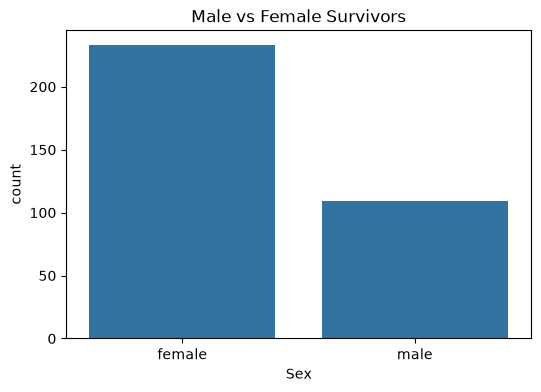

In [31]:
plt.figure(figsize=(6,4))
sns.countplot(x="Sex", data=survivors)
plt.title("Male vs Female Survivors")
plt.show()

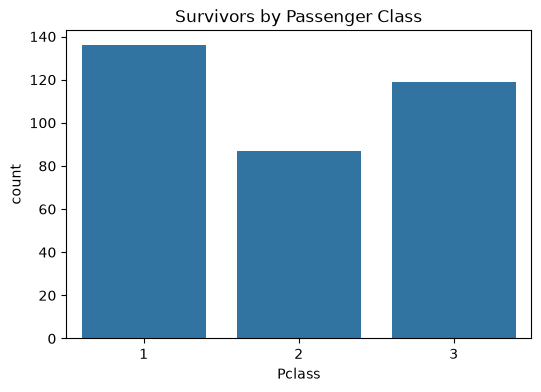

In [32]:
## Question 10

#Display a count plot of survived people in Passenger Class.
plt.figure(figsize=(6,4))
sns.countplot(x="Pclass", data=survivors)
plt.title("Survivors by Passenger Class")
plt.show()

In [33]:
survivors["Pclass"].value_counts()

Pclass
1    136
3    119
2     87
Name: count, dtype: int64

### Observation

- Passenger class influences survival.
- First-class passengers had better survival compared with lower classes.

In [34]:
correlation = df[numerical_columns].corr()

correlation

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
PassengerId,1.000000,-0.005007,-0.035144,0.036847,-0.057527,-0.001652,0.012658
Survived,-0.005007,1.000000,-0.338481,-0.077221,-0.035322,0.081629,0.257307
Pclass,-0.035144,-0.338481,1.000000,-0.369226,0.083081,0.018443,-0.549500
Age,0.036847,-0.077221,-0.369226,1.000000,-0.308247,-0.189119,0.096067
SibSp,-0.057527,-0.035322,0.083081,-0.308247,1.000000,0.414838,0.159651
Parch,-0.001652,0.081629,0.018443,-0.189119,0.414838,1.000000,0.216225
Fare,0.012658,0.257307,-0.549500,0.096067,0.159651,0.216225,1.000000


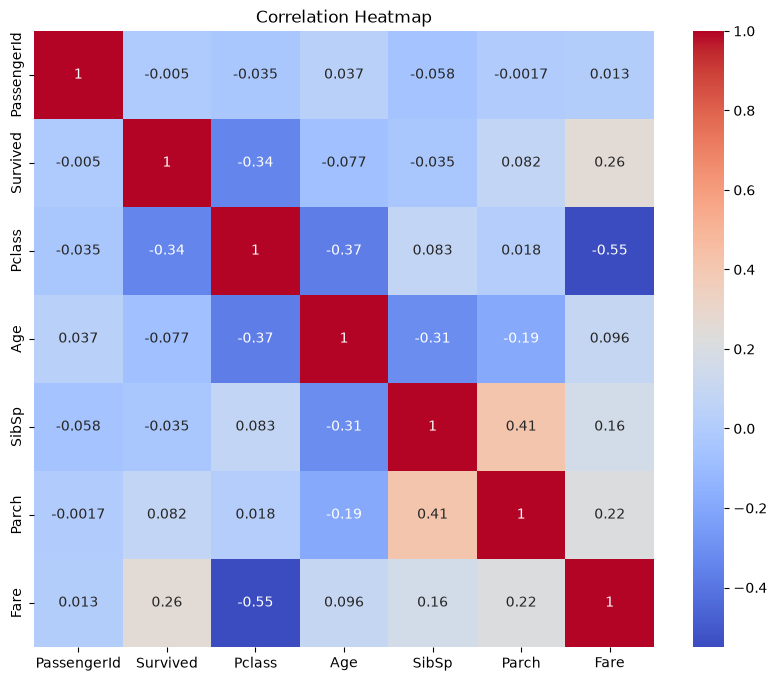

In [35]:
plt.figure(figsize=(10,8))

sns.heatmap(correlation,
            annot=True,
            cmap="coolwarm")

plt.title("Correlation Heatmap")

plt.show()

### Observation

- Most numerical features show weak correlations.
- Fare has a moderate positive relationship with Pclass and survival.
- No extremely strong correlations are present.

In [36]:
corr = df.select_dtypes(include=np.number).corr()

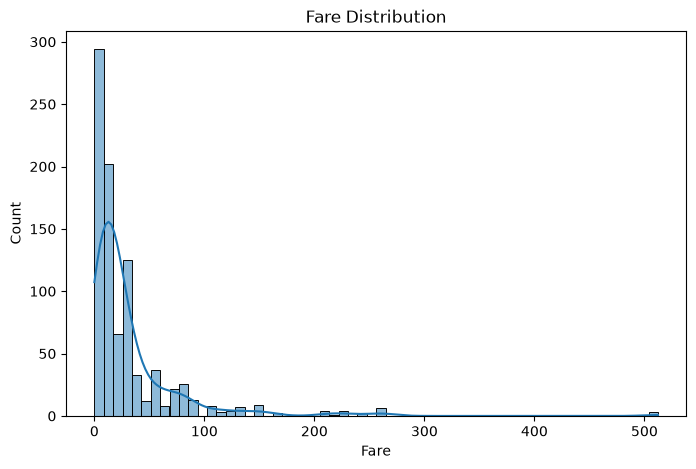

In [37]:
plt.figure(figsize=(8,5))

sns.histplot(df["Fare"], kde=True)

plt.title("Fare Distribution")

plt.show()

### Observation

- Fare distribution is highly right-skewed.
- Most passengers paid relatively low fares.
- A few passengers paid very high fares, indicating outliers.

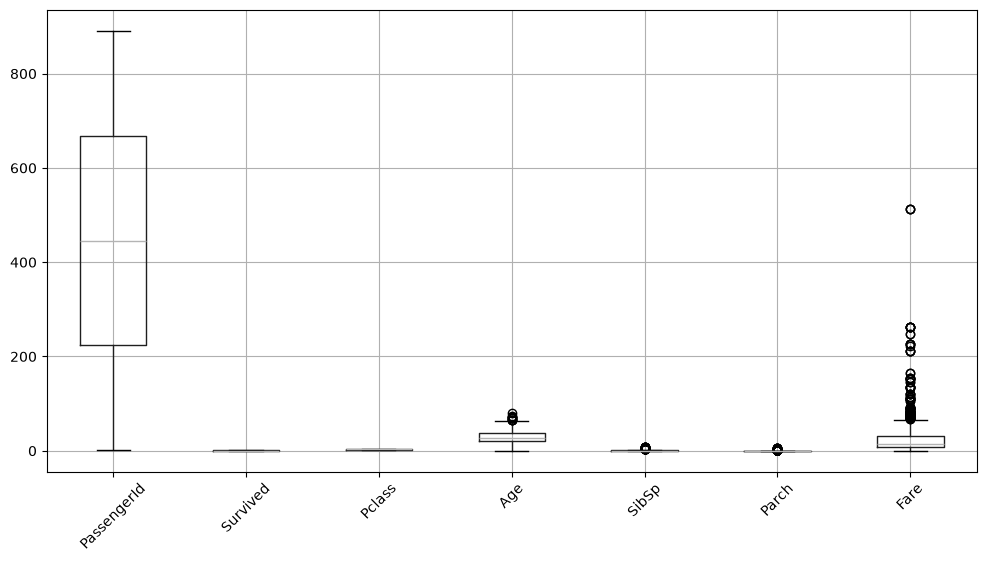

In [38]:
plt.figure(figsize=(12,6))

df[numerical_columns].boxplot()

plt.xticks(rotation=45)

plt.show()

### Observation

- Outliers are present in Age and Fare.
- Most numerical variables are not perfectly normally distributed.
- Boxplots help identify extreme observations.

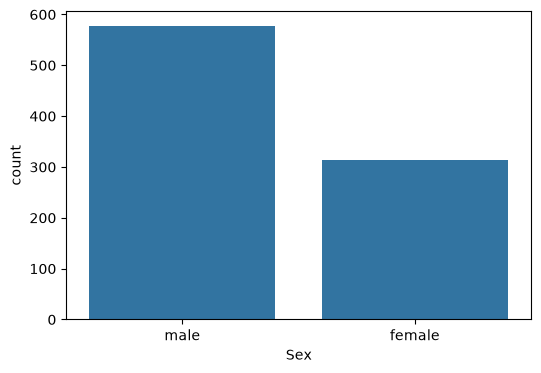

In [39]:
plt.figure(figsize=(6,4))

sns.countplot(x="Sex", data=df)

plt.show()

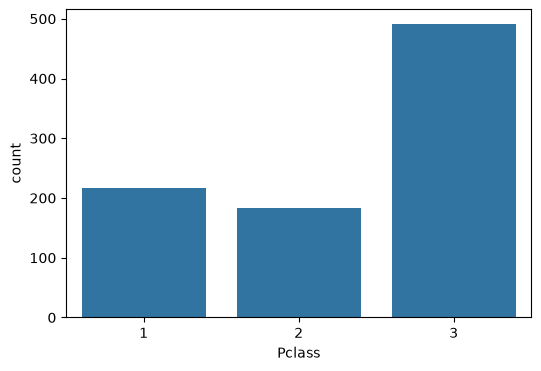

In [40]:
plt.figure(figsize=(6,4))

sns.countplot(x="Pclass", data=df)

plt.show()

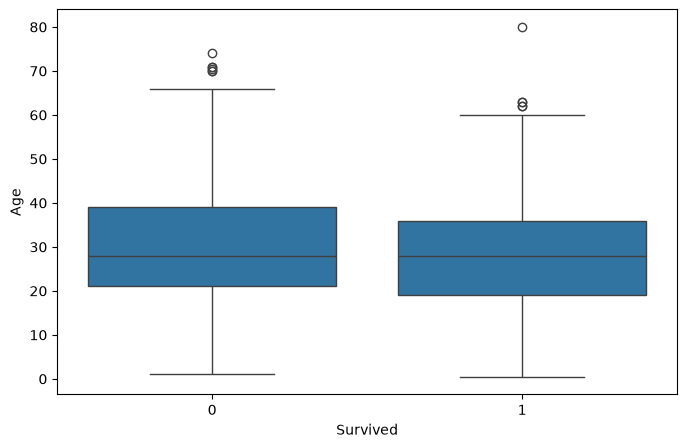

In [41]:
plt.figure(figsize=(8,5))

sns.boxplot(x="Survived",
            y="Age",
            data=df)

plt.show()

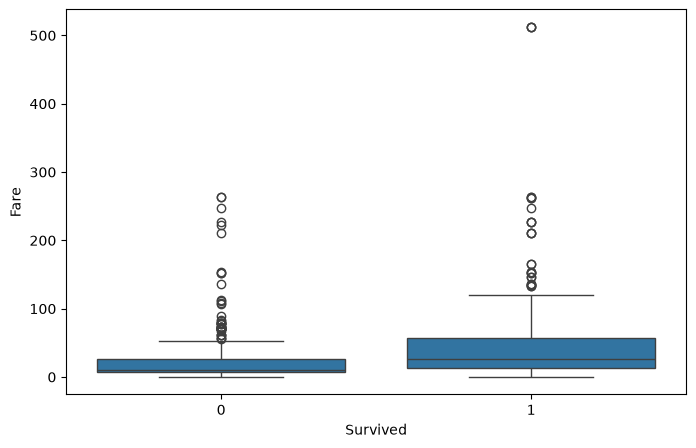

In [42]:
plt.figure(figsize=(8,5))

sns.boxplot(x="Survived",
            y="Fare",
            data=df)

plt.show()

# Conclusion

- The Titanic dataset contained missing values mainly in the Age and Cabin columns.
- Duplicate records were checked and removed.
- Female passengers showed better survival than males.
- Passenger class influenced survival.
- Exploratory Data Analysis helped identify relationships among Age, Fare, Passenger Class, and Survival.